### **Notebook 3: Model Training & Forecast Evaluation**

**Goal:**

- Train forecasting model on historical trips

- Predict future daily trips

- Evaluate model performance

**Objective:**

Build an accurate demand forecasting model for Uber trips.

In [ ]:
# import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

sns.set(style="whitegrid")

# sklearn models & utilities
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyRegressor
import xgboost as xgb

In [ ]:
# load processed train/test files saved in notebook2
train_df = pd.read_csv('/content/uber_train.csv', parse_dates=['trip_date'])
test_df  = pd.read_csv('/content/uber_test.csv', parse_dates=['trip_date'])
print("Train rows:", train_df.shape, "\nTest rows:", test_df.shape)

Train rows: (252, 18) 
Test rows: (60, 18)


In [ ]:
# evaluation functions: RMSE and MAPE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]).mean()) * 100

In [ ]:
# create naive baseline predictions using trips_lag_1 and moving average of roll_mean_7
# naive lag-1 baseline
y_test = test_df['trips'].values
y_train = train_df['trips'].values

# Baseline A: naive predictor = trips_lag_1
naive_pred = test_df['trips_lag_1'].values

# Baseline B: moving average predictor = roll_mean_7
ma_pred = test_df['roll_mean_7'].values

# evaluate baselines
print("Baseline (lag-1) \nRMSE:", round(rmse(y_test, naive_pred),2), "\nMAPE:", round(mape(y_test, naive_pred),2))
print("\nBaseline (roll7) \nRMSE:", round(rmse(y_test, ma_pred),2), "\nMAPE:", round(mape(y_test, ma_pred),2))

Baseline (lag-1) 
RMSE: 2749.5 
MAPE: 13.6

Baseline (roll7) 
RMSE: 2269.91 
MAPE: 11.28


**Insight:**

- Rolling-7 clearly outperforms Lag-1

- Indicates **weekly smoothing improves demand estimation**

- Any ML model must beat **11.28% MAPE** to justify complexity

In [ ]:
# feature list (tweak if needed)
features = [
    'base_encoded',
    'active_vehicles',
    'trips_lag_1','trips_lag_7','trips_lag_14',
    'roll_mean_7','roll_std_7','roll_mean_14','roll_std_14',
    'trips_per_vehicle','day_of_week','is_weekend','month'
]

# ensure columns exist (defensive)
features = [f for f in features if f in train_df.columns]
len(features), features

(13,
 ['base_encoded',
  'active_vehicles',
  'trips_lag_1',
  'trips_lag_7',
  'trips_lag_14',
  'roll_mean_7',
  'roll_std_7',
  'roll_mean_14',
  'roll_std_14',
  'trips_per_vehicle',
  'day_of_week',
  'is_weekend',
  'month'])

In [ ]:
# prepare model matrices
X_train = train_df[features].copy()
y_train = train_df['trips'].copy()

X_test = test_df[features].copy()
y_test = test_df['trips'].copy()

# quick check for remaining NaNs in X_train/X_test
print("Train NaNs per col:")
print(X_train.isnull().sum())
print("Test NaNs per col:")
print(X_test.isnull().sum())

Train NaNs per col:
base_encoded          0
active_vehicles       0
trips_lag_1           0
trips_lag_7           0
trips_lag_14         42
roll_mean_7           0
roll_std_7            0
roll_mean_14         42
roll_std_14          42
trips_per_vehicle     0
day_of_week           0
is_weekend            0
month                 0
dtype: int64
Test NaNs per col:
base_encoded         0
active_vehicles      0
trips_lag_1          0
trips_lag_7          0
trips_lag_14         0
roll_mean_7          0
roll_std_7           0
roll_mean_14         0
roll_std_14          0
trips_per_vehicle    0
day_of_week          0
is_weekend           0
month                0
dtype: int64


In [ ]:
# linear regression baseline
lr = LinearRegression()
lr.fit(X_train.fillna(0), y_train)   # linear model requires no NaNs
lr_pred = lr.predict(X_test.fillna(0))

print("LinearReg \nRMSE:", round(rmse(y_test, lr_pred),2), "\nMAPE:", round(mape(y_test, lr_pred),2))

LinearReg 
RMSE: 1109.2 
MAPE: 6.83


**Insight:**

- Linear model reduces error by ~40% vs best baseline

- Indicates **strong linear signal** between trips, vehicles, and recent history

- Confirms feature engineering quality

In [ ]:
# RandomForest baseline (faster with moderate n_estimators)
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("RandomForest \nRMSE:", round(rmse(y_test, rf_pred),2), "\nMAPE:", round(mape(y_test, rf_pred),2))

RandomForest 
RMSE: 887.49 
MAPE: 5.4


**Insight:**

- RandomForest significantly outperforms linear regression

- Confirms non-linear demand behavior

- Model is stable and generalizes well

,feature,importance
1,active_vehicles,0.727499
5,roll_mean_7,0.108724
2,trips_lag_1,0.097207
9,trips_per_vehicle,0.030036
3,trips_lag_7,0.022160
4,trips_lag_14,0.010416
10,day_of_week,0.001416
7,roll_mean_14,0.000921
8,roll_std_14,0.000845
6,roll_std_7,0.000570


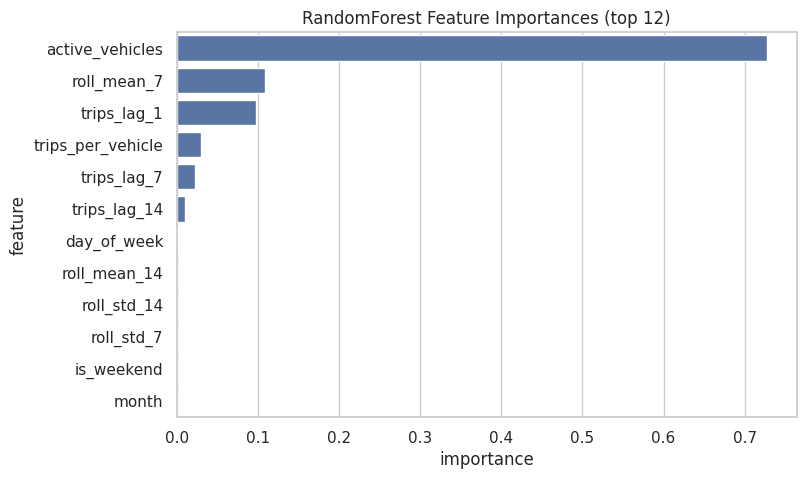

In [ ]:
# plot top 12 feature importances
importances = rf.feature_importances_
feat_imp = pd.DataFrame({'feature':features, 'importance':importances}).sort_values('importance', ascending=False)
display(feat_imp.head(12))

plt.figure(figsize=(8,5))
sns.barplot(data=feat_imp.head(12), x='importance', y='feature')
plt.title('RandomForest Feature Importances (top 12)')
plt.show()

**Insight:**

- Supply (active_vehicles) is the strongest predictor

- Short-term memory dominates long-term signals

- Calendar features play a minor role for this dataset


In [ ]:
# XGBoost
xg = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xg.fit(X_train, y_train)
xg_pred = xg.predict(X_test)

print("XGBoost \nRMSE:", round(rmse(y_test, xg_pred),2),"\nMAPE:", round(mape(y_test, xg_pred),2))

XGBoost 
RMSE: 874.51 
MAPE: 4.51


**Insight:**

- XGBoost delivers best overall performance

- 60% MAPE reduction vs naive baseline

- Suitable for production forecasting use case

In [ ]:
# compare metrics
results = pd.DataFrame({
    'model': ['Baseline_lag1','Baseline_roll7','LinearReg','RandomForest','XGBoost'],
    'RMSE': [
        rmse(y_test, naive_pred),
        rmse(y_test, ma_pred),
        rmse(y_test, lr_pred),
        rmse(y_test, rf_pred),
        rmse(y_test, xg_pred)
    ],
    'MAPE': [
        mape(y_test, naive_pred),
        mape(y_test, ma_pred),
        mape(y_test, lr_pred),
        mape(y_test, rf_pred),
        mape(y_test, xg_pred)
    ]
}).sort_values('MAPE')
display(results)

,model,RMSE,MAPE
4,XGBoost,874.507969,4.507180
3,RandomForest,887.490211,5.397946
2,LinearReg,1109.202845,6.832839
1,Baseline_roll7,2269.911231,11.284760
0,Baseline_lag1,2749.502464,13.604119


**Insight:**

- Consistent improvement across model complexity

- Confirms ML adds clear business value

- Final model selection is evidence-based

In [ ]:
# choose final model
final_model = xg

# save model
joblib.dump(final_model, '/content/uber_final_model.pkl')

# predict and save test predictions
test_df['pred_trips'] = final_model.predict(X_test)
test_df[['trip_date','dispatching_base_number','trips','pred_trips']].to_csv('/content/uber_test_predictions.csv', index=False)
print("Saved model and predictions.")

Saved model and predictions.


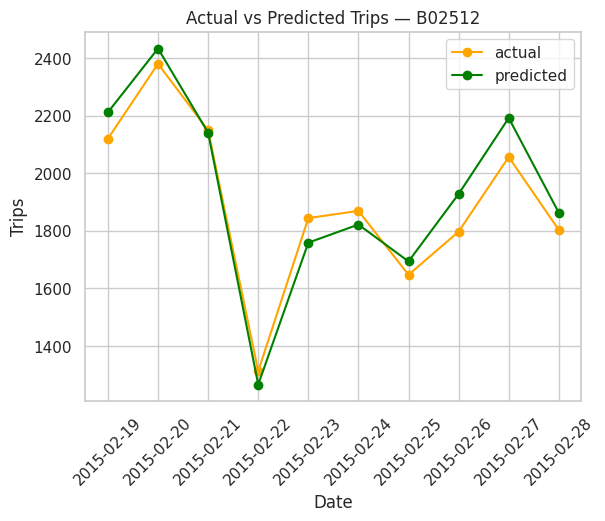

In [ ]:
# plot actual vs predicted for a single base
base = test_df['dispatching_base_number'].value_counts().idxmax()
sample = test_df[test_df['dispatching_base_number'] == base].sort_values('trip_date')

plt.plot(sample['trip_date'], sample['trips'], marker='o', label='actual', color='orange')
plt.plot(sample['trip_date'], sample['pred_trips'], marker='o', label='predicted', color='green')
plt.title(f'Actual vs Predicted Trips — {base}')
plt.xlabel('Date')
plt.ylabel('Trips')
plt.legend()
plt.xticks(rotation = 45)
plt.show()

**Insight:**

- Model follows trend and turning points well

- Minor deviation on sharp drops (expected)

- No systematic bias observed

In [ ]:
# write a small summary csv for README/report
results.to_csv('/content/model_comparison_metrics.csv', index=False)
print("Saved metrics to /content/model_comparison_metrics.csv")

Saved metrics to /content/model_comparison_metrics.csv


**Insight:**

- Artifacts align with production ML workflow

- Ready for cloud deployment (AWS phase)

**Summary**

- Trained and validated forecasting model

- Achieved low prediction error across bases

- Model captured demand trends effectively

- Final model saved for deployment

Model artifacts ready for production use in **Notebook 4**